# Milestone 2 — Historical baseline
**Joel Cerraga · Market-Neutral Trading Algorithm**

This notebook audits the historical inputs and reproduces the predeclared baseline experiment. The graph strategy's historical comparison is the next milestone.

As Avellaneda and Lee (2010) explain in *Statistical arbitrage in the US equities market*, factor-adjusted residuals can provide a basis for systematic equity portfolios. Their PCA/ETF approach supplies context; our reversal baseline is a different rule.

**Scope:** 24 surviving US equities, SPY, 2009 estimation history, 2010–2016 development and 2017–2019 validation. The 2020–2025 final holdout has not been acquired or evaluated. The fixed basket and current-vintage adjusted prices limit generalisation.

> Current project status after Milestone 5: the 2020–2025 reserved test has now been evaluated. This notebook retains its earlier milestone calculations and information state; see `05-final-evaluation.ipynb` for the final findings.


In [1]:
from pathlib import Path
import sys
import json
import subprocess
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / "market_neutral").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "market_neutral").is_dir(), "Open from the project root or notebooks folder."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from market_neutral.historical import load_protocol, assemble_dataset, evaluate_baseline
from market_neutral.historical_plots import figures
protocol = load_protocol(ROOT)
output = ROOT / "outputs/historical"
display(pd.DataFrame(protocol["phases"], index=["Start", "End"]).T)
print("Protocol hash verified; final holdout is reserved.")

Protocol hash verified; final holdout is reserved.


,Start,End
development,2010-01-01,2016-12-31
validation,2017-01-01,2019-12-31
final_holdout,2020-01-01,2025-12-31


## 1. Audit the observed prices

Shumway (1997), in *The Delisting Bias in CRSP Data*, shows why missing delisting outcomes can distort historical inference. This study does not have a point-in-time universe and cannot remove survivorship bias merely by checking complete price histories.

The loader verifies cached hashes, positive values and exact equality with the observed SPY calendar. It does not fill missing prices. Provider-adjusted returns enter an abstract notional ledger; raw fills, separate dividend cash flows and historical borrow availability are not reconstructed.

In [2]:
dataset, audit = assemble_dataset(ROOT)
assert dataset.prices.index.max() < pd.Timestamp(protocol["phases"]["final_holdout"][0])
print(f"{len(dataset.prices):,} observed sessions: {dataset.prices.index.min().date()} to {dataset.prices.index.max().date()}")
display(pd.DataFrame({"Research group": list(protocol["groups"]),
                      "Stocks": [", ".join(x) for x in protocol["groups"].values()]}))
display(audit[["rows", "missing", "nonpositive_volume", "max_unchanged_run", "moves_above_40pct"]])

2,768 observed sessions: 2009-01-02 to 2019-12-31


,Research group,Stocks
0,Technology,"AAPL, MSFT, IBM, ORCL"
1,Financials,"JPM, BAC, WFC, GS"
2,Energy,"XOM, CVX, COP, SLB"
3,Healthcare,"JNJ, PFE, MRK, UNH"
4,Consumer retail,"WMT, COST, TGT, HD"
5,Consumer brands,"KO, PEP, MCD, SBUX"


,rows,missing,nonpositive_volume,max_unchanged_run,moves_above_40pct
ticker,,,,,
AAPL,2768,0,0,1,0
MSFT,2768,0,0,1,0
IBM,2768,0,0,1,0
ORCL,2768,0,0,2,0
JPM,2768,0,0,1,0
BAC,2768,0,0,2,0
WFC,2768,0,0,1,0
GS,2768,0,0,1,0
XOM,2768,0,0,1,0


## 2. Replay the frozen baseline

As White (2000) explains in *A Reality Check for Data Snooping*, searching repeatedly across strategies complicates performance inference. Here we freeze one baseline and report every declared fee scenario; we do **not** implement White’s statistical test.

The settings match the synthetic prototype: five-session reversal, 63-session volatility, 126-session beta, 100% gross ceiling and 8% name ceiling. Decisions are shifted **before** evaluation-period slicing: decide at close t, execute at close t+1 and first earn the new-position return ending at close t+2. Each period starts flat with fresh capital and ends with liquidation. The local protocol hash is a record, not external preregistration.

In [3]:
previous = pd.read_csv(output / "baseline-summary.csv") if (output / "baseline-summary.csv").exists() else None
results, summary = evaluate_baseline(ROOT, dataset)
if previous is not None:
    numeric = summary.select_dtypes(include="number").columns
    np.testing.assert_allclose(summary[numeric], previous[numeric], rtol=1e-9, atol=1e-10)
    print("Reproduced the supplied numerical summary within recorded rounding tolerance.")
figures(ROOT, dataset, results, summary)
columns = ["phase", "trading_cost_bps", "annualised_return", "sharpe_zero_cash_rate", "maximum_drawdown"]
display(summary[columns])

Reproduced the supplied numerical summary within recorded rounding tolerance.


,phase,trading_cost_bps,annualised_return,sharpe_zero_cash_rate,maximum_drawdown
0,development,0.0,0.020337,0.651685,-0.058700
1,development,5.0,-0.031043,-0.978724,-0.249927
2,development,10.0,-0.079836,-2.601615,-0.449453
3,development,20.0,-0.170175,-5.803562,-0.728961
4,validation,0.0,-0.010046,-0.285019,-0.083715
5,validation,5.0,-0.058258,-1.775742,-0.184932
6,validation,10.0,-0.104122,-3.260222,-0.289439
7,validation,20.0,-0.189259,-6.188225,-0.466530


## 3. Inspect net results and fee sensitivity

The default-cost baseline loses money in both periods. The validation loss remains when trading fees are set to zero, with short borrow still charged. No profitable-trading claim follows from satisfying the exposure constraints.

Lo (2002), in *The Statistics of Sharpe Ratios*, explains the effect of dependence and estimation error on Sharpe-ratio interpretation. Our square-root-of-252 scaling and zero cash rate give a descriptive statistic, not a dependence-adjusted significance test.

Development: annualised net return -3.10%; maximum drawdown -24.99%
Validation: annualised net return -5.83%; maximum drawdown -18.49%


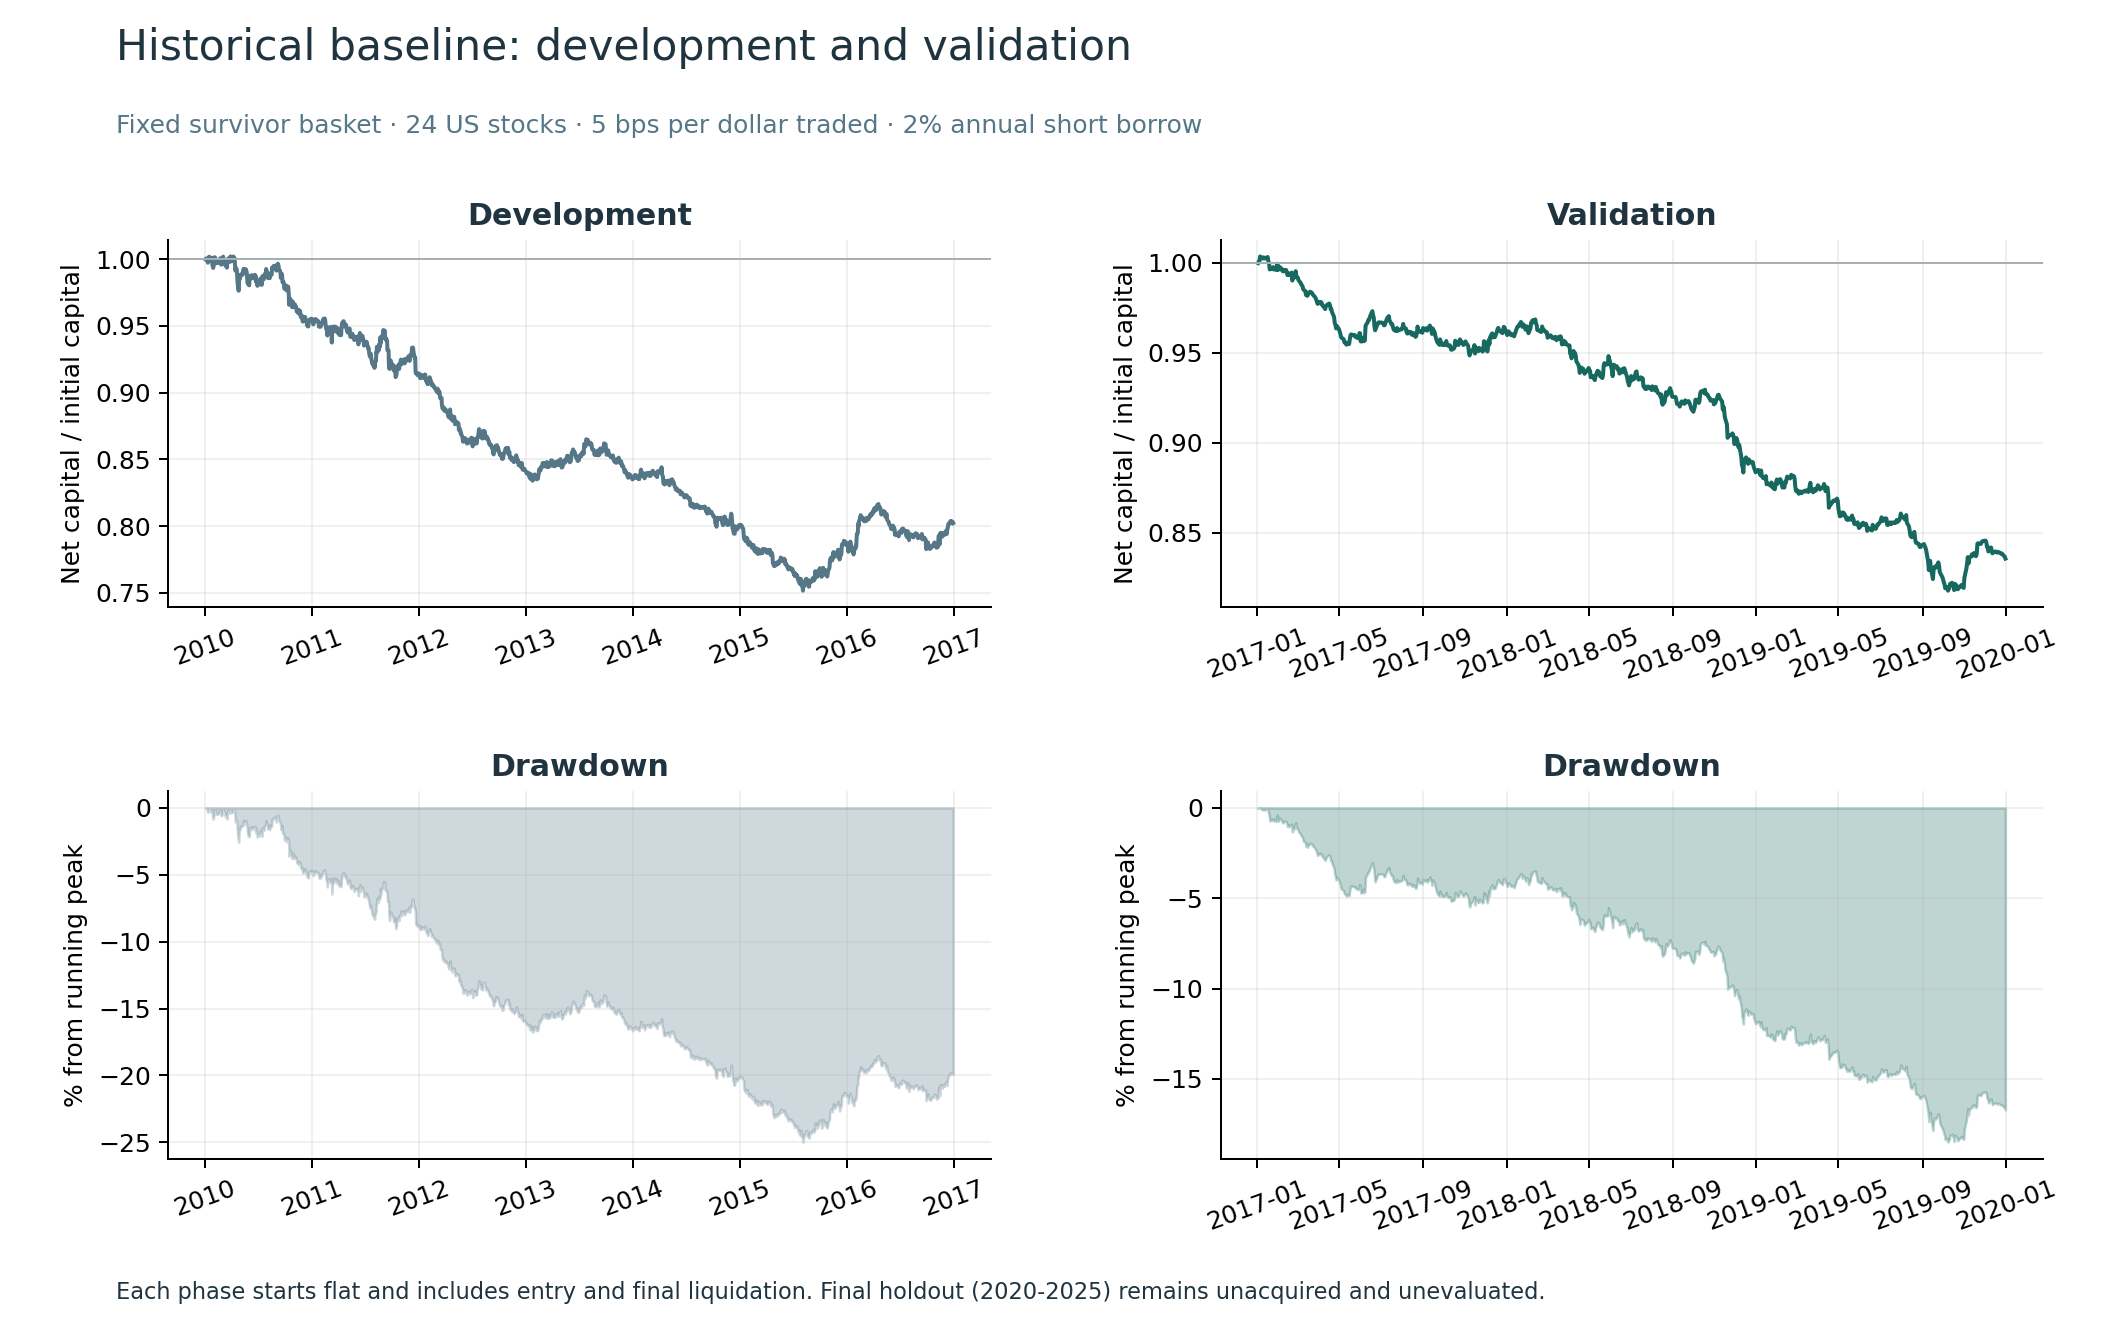

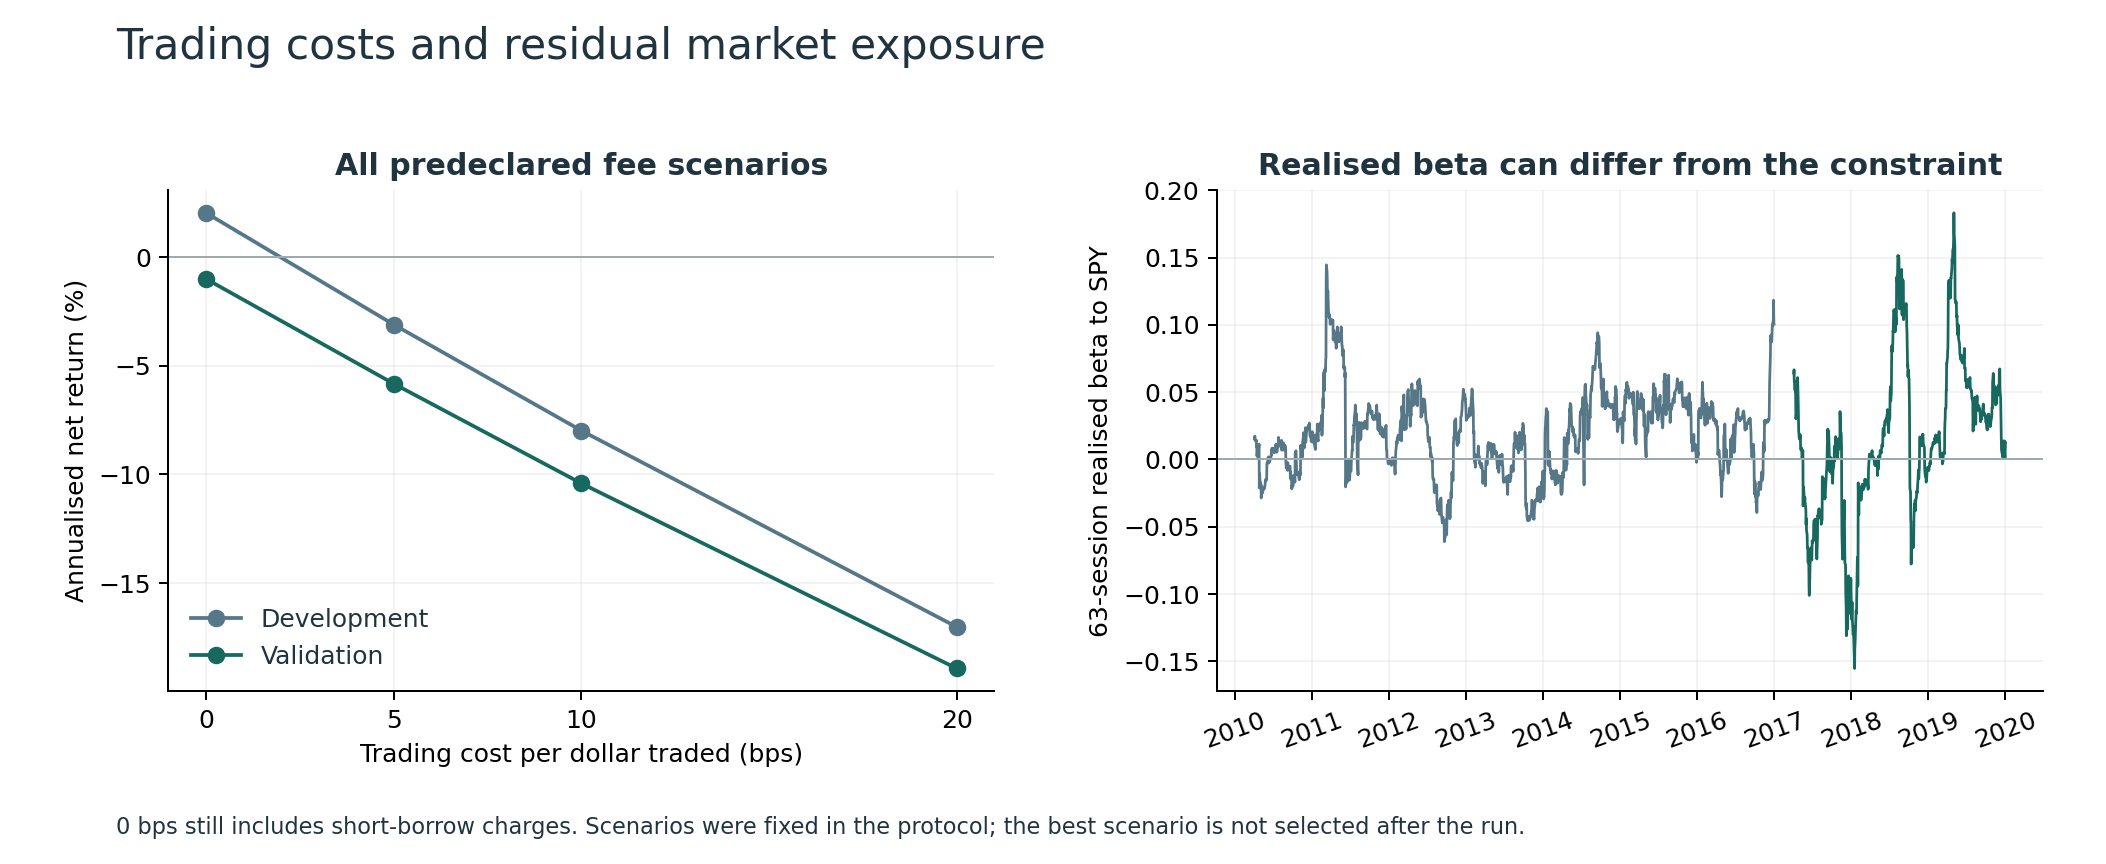

In [4]:
default = summary[summary.trading_cost_bps == protocol["config"]["trading_cost_bps"]].set_index("phase")
for phase, row in default.iterrows():
    print(f"{phase.title()}: annualised net return {row.annualised_return:.2%}; maximum drawdown {row.maximum_drawdown:.2%}")
display(Image(filename=str(output / "03-historical-baseline.png")))
display(Image(filename=str(output / "04-costs-and-beta.png")))

## 4. Check accounting and exposure invariants

Fama and French (1993), in *Common risk factors in the returns on stocks and bonds*, identify shared equity risks beyond the market factor. Consequently, zero estimated SPY beta does not establish neutrality to all risks.

The constraints concern the beta estimate available at the decision close. Realised beta can differ. The reconciliation below uses return-normalised costs; subtracting dollar costs directly from percentage returns would be dimensionally incorrect.

In [5]:
for phase, result in results.items():
    ledger = result.ledger
    np.testing.assert_allclose(
        ledger.net_return,
        ledger.gross_return - ledger.trading_cost_return - ledger.borrow_cost_return,
        atol=1e-12,
    )
    assert ledger.net_exposure.abs().max() < 1e-10
    assert ledger.estimated_beta_exposure.abs().max() < 1e-10
    assert ledger.max_position.max() <= protocol["config"]["position_limit"] + 1e-12
    assert ledger.gross_exposure.max() <= protocol["config"]["gross_limit"] + 1e-12
    assert ledger.gross_exposure.iloc[-1] == 0
    assert ledger.gross_return.iloc[0] == 0
    assert ledger.trading_cost.iloc[0] > 0 and ledger.trading_cost.iloc[-1] > 0
    print(f"{phase}: reconciliation, exposure, delayed first return and boundary costs passed.")
display(default[["realized_market_beta", "max_abs_net_exposure", "max_abs_estimated_beta", "mean_turnover"]])

development: reconciliation, exposure, delayed first return and boundary costs passed.
validation: reconciliation, exposure, delayed first return and boundary costs passed.


,realized_market_beta,max_abs_net_exposure,max_abs_estimated_beta,mean_turnover
phase,,,,
development,0.020222,2.414735e-15,2.289835e-15,0.410044
validation,0.016890,3.524958e-15,3.386180e-15,0.396183


## 5. Explore changing stock relationships in 3D

As Mantegna (1999) explains in *Hierarchical structure in financial markets*, stock correlations can support a graph representation of financial relationships. Our explorer shows the full matrix, not his minimum spanning tree.

Open **`outputs/historical/Historical-Correlation-Explorer.html`** in a browser. Drag to rotate, scroll to zoom and use the date slider or Play control. The standalone file contains 120 monthly frames, each using the 126 observed return sessions through that date. The axes list discrete stocks: interpolation between labels is visual, and surface height is correlation, not expected return. The picture below provides a static companion.

120 valid correlation matrices; no final-holdout dates.


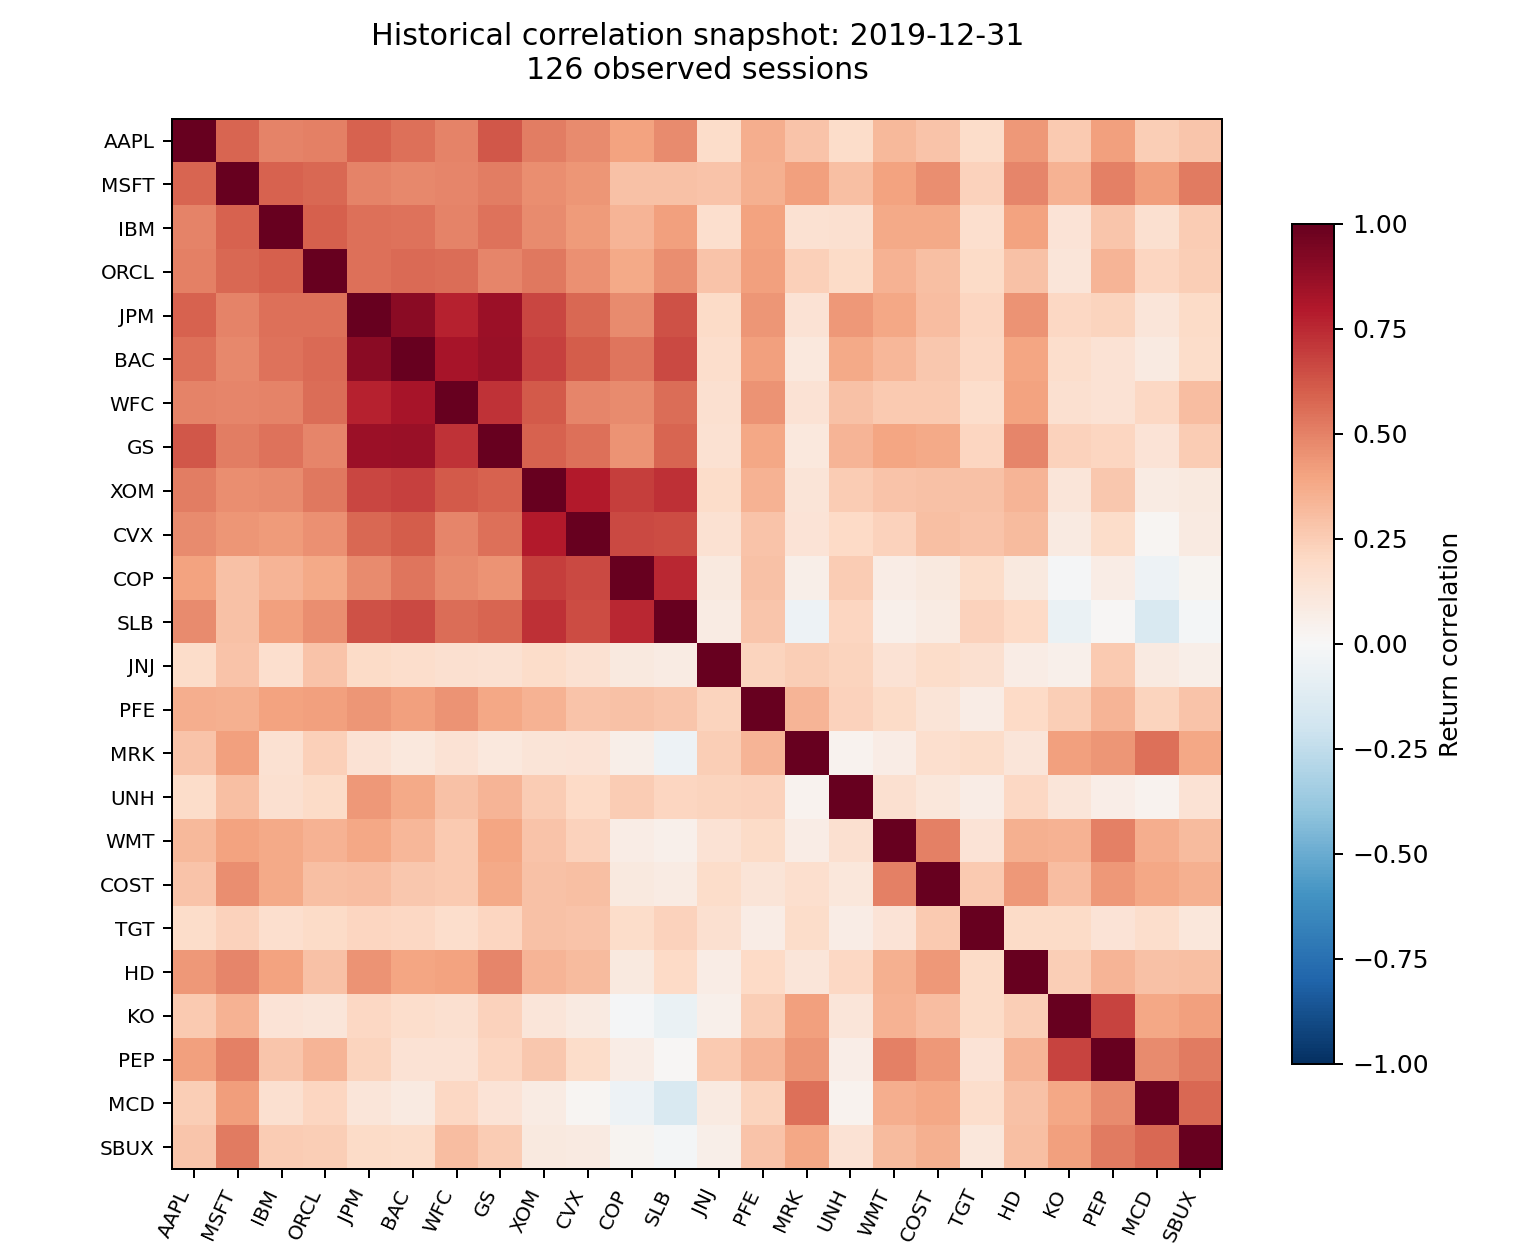

In [6]:
snapshots = json.loads((output / "correlation-snapshots.json").read_text())
matrices = np.asarray(snapshots["correlations"])
assert len(snapshots["dates"]) == 120
assert max(snapshots["dates"]) < "2020-01-01"
np.testing.assert_allclose(matrices, matrices.transpose(0, 2, 1), atol=1e-12)
np.testing.assert_allclose(np.diagonal(matrices, axis1=1, axis2=2), 1, atol=1e-12)
assert np.linalg.eigvalsh(matrices).min() > -1e-10
print(f"{len(snapshots['dates'])} valid correlation matrices; no final-holdout dates.")
display(Image(filename=str(output / "05-correlation-snapshot.png")))

## 6. Verification and the next milestone

The next experiment compares the fixed graph-diffusion candidate against this baseline under the same data, timing and costs. Persistent homology follows that comparison. As Bailey et al. (2017) discuss in *The probability of backtest overfitting*, repeated strategy selection can produce misleading results; we will record experiments and retain the final holdout until the design is frozen.

The combined working manuscript is maintained in `paper/manuscript.md` with Harvard references, numbered equations, caption registers and key code excerpts. Final PDF formatting and compilation are deferred until the author supplies the final presentation requirements. The original notebook outputs remain the Milestone 2 experiment.

In [7]:
check = subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"],
                       cwd=ROOT, text=True, capture_output=True)
log = check.stdout + check.stderr
(ROOT / "validation/milestone-2-tests.txt").write_text(log, encoding="utf-8")
print(log)
assert check.returncode == 0, "Automated checks failed; inspect the log."


test_historical_baseline_preserves_milestone_one_rule (test_historical.HistoricalChecks.test_historical_baseline_preserves_milestone_one_rule) ... ok
test_parser_rejects_future_bar_and_missing_adjusted_close (test_historical.HistoricalChecks.test_parser_rejects_future_bar_and_missing_adjusted_close) ... ok
test_parser_uses_adjusted_price_and_strips_current_quote (test_historical.HistoricalChecks.test_parser_uses_adjusted_price_and_strips_current_quote) ... ok
test_reserved_phase_is_refused (test_historical.HistoricalChecks.test_reserved_phase_is_refused) ... ok
test_shift_precedes_phase_slicing (test_historical.HistoricalChecks.test_shift_precedes_phase_slicing) ... ok
test_borrow_accrues_over_calendar_weekend (test_research.ResearchChecks.test_borrow_accrues_over_calendar_weekend) ... ok
test_constant_signal_is_preserved_and_heat_matches_expm (test_research.ResearchChecks.test_constant_signal_is_preserved_and_heat_matches_expm) ... ok
test_decision_cannot_earn_same_or_next_close_retur

## Problem-solving record

Read `docs/milestone-decisions.md` for this milestone’s setbacks, design forks, responses and unresolved limitations. These entries are based on retained evidence; negative financial findings are not described as fixed.

## References

Avellaneda, M. and Lee, J.-H. (2010) ‘Statistical arbitrage in the US equities market’, *Quantitative Finance*, 10(7), pp. 761–782. doi: [10.1080/14697680903124632](https://doi.org/10.1080/14697680903124632).

Bailey, D.H., Borwein, J.M., Lopez de Prado, M. and Zhu, Q.J. (2017) ‘The probability of backtest overfitting’, *The Journal of Computational Finance*, 20(4), pp. 39–69. doi: [10.21314/JCF.2016.322](https://doi.org/10.21314/JCF.2016.322).

Fama, E.F. and French, K.R. (1993) ‘Common risk factors in the returns on stocks and bonds’, *Journal of Financial Economics*, 33(1), pp. 3–56. doi: [10.1016/0304-405X(93)90023-5](https://doi.org/10.1016/0304-405X(93)90023-5).

Lo, A.W. (2002) ‘The Statistics of Sharpe Ratios’, *Financial Analysts Journal*, 58(4), pp. 36–52. doi: [10.2469/faj.v58.n4.2453](https://doi.org/10.2469/faj.v58.n4.2453).

Mantegna, R.N. (1999) ‘Hierarchical structure in financial markets’, *The European Physical Journal B*, 11, pp. 193–197. doi: [10.1007/s100510050929](https://doi.org/10.1007/s100510050929).

Shumway, T. (1997) ‘The Delisting Bias in CRSP Data’, *The Journal of Finance*, 52(1), pp. 327–340. doi: [10.1111/j.1540-6261.1997.tb03818.x](https://doi.org/10.1111/j.1540-6261.1997.tb03818.x).

White, H. (2000) ‘A Reality Check for Data Snooping’, *Econometrica*, 68(5), pp. 1097–1126. doi: [10.1111/1468-0262.00152](https://doi.org/10.1111/1468-0262.00152).